# Scattering anisotropy factor $g(\lambda)$ of the LSU amorphous networks
### single-scattering, no FDTD

Computes the **bulk single-scattering anisotropy factor** $g=\langle\cos\theta\rangle$ of one **or several**
connected amorphous dielectric networks from their `*_ends.txt` rod files (the vertex count $N$ is
auto-extracted from each filename), given the index contrast and rod radius. You choose the
**wavelength / frequency range and the number of points**.

**What is reliable here:** $g(\lambda)$ — the *normalized* single-scattering phase-function anisotropy — in
the **weak-scattering / independent-scattering (ISA) window**: *off* the photonic gap, where $k\,\ell_s\gg1$,
and *above* the finite-size floor. Points below that floor (long $\lambda$) are computed but **flagged**
($\times$ markers): there $g$ is a finite-size artifact (physically $g\to0$). Because $g$ is *normalized* it
is robust to the contrast magnitude and is the correct structure-factor-weighted transport anisotropy in
that window.

**Deliberately NOT computed (needs full-wave / FDTD):** the mean free paths $\ell_s,\ \ell_t$. A
single-scattering / 2-point effective-medium expansion cannot produce the photonic **band-gap resonance**
(where $\ell_s$ is smallest) and is not quantitative at this contrast. See
**`README.md` → "Scattering anisotropy factor g"** for the physics, methods, validity map and references.
Engine: `scattering_g.py`.

## 1. Configuration

In [ ]:
import numpy as np, re, os
import matplotlib.pyplot as plt
import scattering_g as sg                       # the engine (see scattering_g.py + README)

# ---- inputs: one OR MORE networks (N is auto-extracted from each filename) ------
SAVE=False
ENDS_FILES = [
    "Example/N1000/20260623_lsu_fromrandom_N1000_ends.txt",
    "Example/N4000/20260624_lsu_fromrandom_N4000_ends.txt",
]
N_ROD, N_BG  = 3.3, 1.0        # rod / background refractive index (the FDTD structure uses n_rod=3.3)
MINOR_RADIUS = 0.335           # rod radius [um]
ASPECT_RATIO = 1.0             # 1.0 = isotropic (circular rods)
TARGET_DX    = 0.05            # voxel size [um]; grid per file = round(box/TARGET_DX), so the spatial
                               # resolution is the SAME for every N (rod radius/TARGET_DX = 6.7 here).

# ---- the sweep: YOU choose the range and the number of points -------------------
# The sweep is ALWAYS linearly spaced in FREQUENCY (nu = a/lambda, proportional to 1/lambda). Give either a
# frequency range (SWEEP_BY="nu") or a wavelength range (SWEEP_BY="lambda", converted to freq internally).
SWEEP_BY   = "nu"              # "nu" -> use NU_RANGE (reduced freq a/lambda) ; "lambda" -> use LAM_RANGE (um)
NU_RANGE   = (0.25, 1.0)       # (min, max) reduced FREQUENCY nu=a/lambda (used when SWEEP_BY == "nu")
LAM_RANGE  = (1.4, 11.0)       # (min, max) WAVELENGTH [um]              (used when SWEEP_BY == "lambda")
A_SCALE    = 2.55              # length 'a' for nu=a/lambda [um]; None -> number-density length (=1.144 um).
                               # 2.55 matches the FDTD convention; sets the frequency axis.
N_SWEEP    = 40                # number of points (evenly spaced in frequency)

# ---- analysis options ----------------------------------------------------------
POLARIZED  = False             # False = unpolarized vector-dipole factor (1+cos^2)/2 ; True = scalar
MIN_EWALD_MODES = 6            # per-point RELIABILITY FLAG (a warning, not a floor): points whose Ewald sphere
                               # spans fewer than this many q-shells (dq=2pi/L) are finite-size-limited. ~5 is
                               # the empirical convergence onset; reliable reach grows only as N^(1/3).
SAVE_TAG   = "sweep"

def N_from_name(path):
    """Extract the vertex count N from a filename like '..._N4000_ends.txt' (regex)."""
    m = re.search(r"N(\d+)", os.path.basename(path))
    if not m:
        raise ValueError(f"could not extract N ('N<digits>') from filename: {path}")
    return int(m.group(1))

print(f"{len(ENDS_FILES)} network(s):")
for f in ENDS_FILES:
    print(f"  N = {N_from_name(f):>6}   <-   {f}")

2 network(s):
  N =   1000   <-   Example/N1000/20260623_lsu_fromrandom_N1000_ends.txt
  N =   4000   <-   Example/N4000/20260624_lsu_fromrandom_N4000_ends.txt


## 2. The shared sweep and the per-network $g$ pipeline
`a` for the reduced frequency $\nu=a/\lambda$ is `A_SCALE` (the number-density length $(L^3/N)^{1/3}=1.144\,\mu$m
is $N$-independent, so a single sweep applies to every network). For each file we voxelise $\to$ spectral
density $\to$ effective Ewald index $n_\mathrm{eff}$ (HS-upper) $\to$ $g(\lambda)$, and flag each point's
reliability from how many $q$-shells the Ewald sphere spans.

In [2]:
a_nu = A_SCALE if A_SCALE is not None else (11.44**3/1000)**(1/3)   # 'a' for nu=a/lambda (N-independent)
# ALWAYS linearly spaced in FREQUENCY nu=a/lambda (proportional to 1/lambda); a lambda-range is converted
# to its frequency range first. nu is the natural, FDTD-style axis for a photonic band diagram.
if SWEEP_BY == "nu":
    nus = np.linspace(NU_RANGE[0], NU_RANGE[1], N_SWEEP)
else:  # "lambda" range -> equivalent frequency range
    nus = np.linspace(a_nu/LAM_RANGE[1], a_nu/LAM_RANGE[0], N_SWEEP)
lams = a_nu/nus
k0s  = 2*np.pi/lams
print(f"sweep (LINEAR IN FREQUENCY nu=a/lam, a={a_nu:.2f} um): nu in [{nus.min():.3f}, {nus.max():.3f}]  |  "
      f"lambda in [{lams.min():.2f}, {lams.max():.2f}] um  |  {N_SWEEP} pts")

def compute_g(ends_file):
    """Voxelise one network and return g(lambda) on the shared sweep, with per-point reliability flags."""
    N   = N_from_name(ends_file)
    box = (N/1000.0*11.44**3)**(1/3)
    G   = max(64, int(round(box/TARGET_DX)))          # constant spatial resolution across N
    rods = np.loadtxt(ends_file)
    V = sg.voxelize_network(rods, N=N, n_rod=N_ROD, n_bg=N_BG, minor_radius=MINOR_RADIUS,
                            aspect_ratio=ASPECT_RATIO, grid_size=G)
    eps, ff, n_av = V["eps"], V["ff"], V["n_av"]
    _, _, interp3d, qc, chi = sg.spectral_density(eps.astype(float), box, nbins=160)
    qci, chii = sg.indicator_spectral_density(eps, box, eps_bg=N_BG**2, nbins=160)
    m = qc > 1.0; q_peak = qc[m][np.argmax(chi[m])]; dq = 2*np.pi/box
    n_eff = sg.strong_contrast_neff_network(2*np.pi/6.0, qci, chii, N_ROD, N_BG, ff, "rods", hs_cap=True)
    g_avg = np.array([sg.g_orientation_avg(interp3d, k0*n_eff, n_inc=14, ndir=2600, polarized=POLARIZED) for k0 in k0s])
    g_iso = np.array([sg.g_isotropic(qc, chi, k0*n_eff, polarized=POLARIZED) for k0 in k0s])
    reliable = (2*k0s*n_eff/dq) >= MIN_EWALD_MODES     # Ewald sphere spans >= MIN_EWALD_MODES q-shells?
    lam_gap  = 4*np.pi*n_eff/q_peak                    # 2 k_eff = q_FSDP (gap vicinity)
    lam_rel_max = lams[reliable].max() if reliable.any() else float("nan")
    print(f"  N={N:>5}: L={box:.2f} um  G={G}  ff={ff:.4f}  n_eff={n_eff:.3f}  q_FSDP={q_peak:.2f} um^-1  "
          f"|  reliable {int(reliable.sum())}/{N_SWEEP} (lambda <= {lam_rel_max:.2f} um)  gap~{lam_gap:.2f} um")
    return dict(N=N, box=box, G=G, ff=ff, n_av=n_av, n_eff=n_eff, q_peak=q_peak,
                g_avg=g_avg, g_iso=g_iso, reliable=reliable, lam_gap=lam_gap,
                qc=qc, chi_field=chi, qci=qci, chi_ind=chii)

sweep (LINEAR IN FREQUENCY nu=a/lam, a=2.55 um): nu in [0.250, 1.000]  |  lambda in [2.55, 10.20] um  |  40 pts


## 3. Validation of the $g$ pipeline
Analytic anchors the spectral-density $g$ must reproduce: the **Rayleigh-Gans-Debye** sphere $g$ (checks
FFT / Ewald sampling / polarization factor / angular integration) and the **Rayleigh limit** $x\to0\Rightarrow g\to0$.

In [3]:
def g_born_sphere(x, boxmult=14, d=0.06):
    G = int(round(boxmult/d)); axc = (np.arange(G)-(G-1)/2)*d
    Xs, Ys, Zs = np.meshgrid(axc, axc, axc, indexing="ij")
    ep = np.where(Xs*Xs+Ys*Ys+Zs*Zs <= 1.0, 2.0, 1.0)
    _,_,_, qcs, chis = sg.spectral_density(ep, G*d, nbins=400)
    return sg.g_isotropic(qcs, chis, x)          # R=1 so k=x

print("Born spectral-density g vs analytic Rayleigh-Gans sphere g:")
print(f"   {'x=kR':>6}{'g_RGD':>9}{'g_Born':>9}")
for x_ in (2.0, 4.0, 6.0):
    print(f"   {x_:6.1f}{sg.g_rgd_sphere(x_):9.4f}{g_born_sphere(x_):9.4f}")
print(f"   Rayleigh limit  g_RGD(x=0.1) = {sg.g_rgd_sphere(0.1):+.4f}  (-> 0)")

Born spectral-density g vs analytic Rayleigh-Gans sphere g:
     x=kR    g_RGD   g_Born
      2.0   0.6075   0.5934
      4.0   0.8742   0.8705
      6.0   0.9345   0.9326
   Rayleigh limit  g_RGD(x=0.1) = +0.0016  (-> 0)


## 4. Compute $g(\lambda)$ for each network

In [4]:
print("computing g for each network (voxelise + FFT + Ewald sweep per file)...")
results = [compute_g(f) for f in ENDS_FILES]

computing g for each network (voxelise + FFT + Ewald sweep per file)...
  N= 1000: L=11.44 um  G=229  ff=0.2237  n_eff=1.629  q_FSDP=3.72 um^-1  |  reliable 31/40 (lambda <= 6.03 um)  gap~5.51 um
  N= 4000: L=18.16 um  G=363  ff=0.2233  n_eff=1.628  q_FSDP=3.72 um^-1  |  reliable 39/40 (lambda <= 9.47 um)  gap~5.50 um


## 5. Spectral density $\tilde\chi_V(q)$ — the structural input to $g$
The single-scattering $g$ is set entirely by the **spectral density** $\tilde\chi_V(q)$ (the connected-network
analog of the structure factor $S(q)$; $p(\theta)\propto\tilde\chi_V(2k_\mathrm{eff}\sin\tfrac\theta2)$).
*Left:* the $\varepsilon$-field spectral density used for $g$, with each network's first sharp diffraction
peak (**FSDP** $q_\mathrm{FSDP}$, dashed) — the Bragg / gap-vicinity scale. *Right:* the two-phase
**indicator** spectral density (log-log), whose low-$q$ suppression is the **near-hyperuniformity** of these
networks. Overlaying several $N$ shows the shape is $N$-converged, with finite-size effects confined to the
lowest $q$ (fewest modes) — the same limit that bounds $g$ at long $\lambda$.

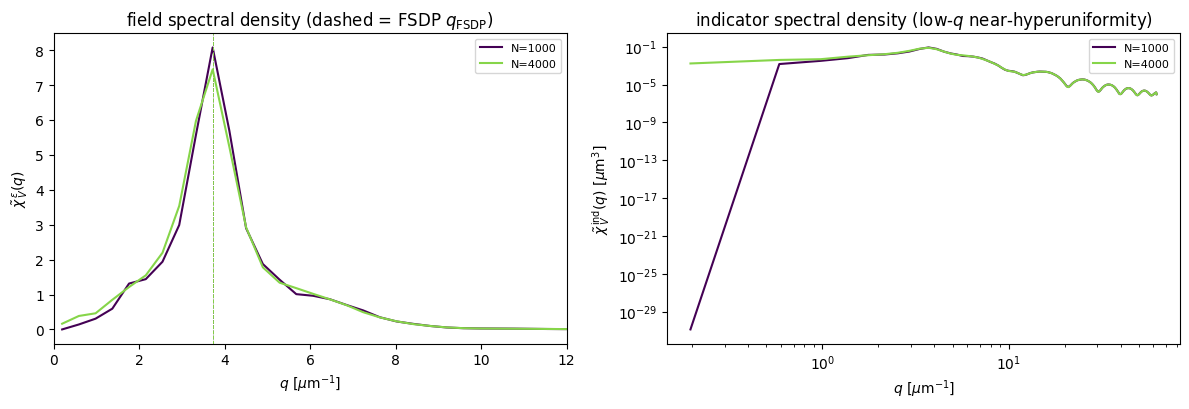

N= 1000: FSDP q_peak = 3.718 um^-1   (gap-vicinity lambda = 5.51 um)
N= 4000: FSDP q_peak = 3.718 um^-1   (gap-vicinity lambda = 5.50 um)


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
colors = plt.cm.viridis(np.linspace(0, 0.82, len(results)))
for R, c in zip(results, colors):
    ax[0].plot(R["qc"], R["chi_field"], color=c, label=f"N={R['N']}")
    ax[0].axvline(R["q_peak"], ls="--", c=c, lw=.7)
    mp = R["qci"] > 0
    ax[1].loglog(R["qci"][mp], R["chi_ind"][mp], color=c, label=f"N={R['N']}")
ax[0].set(xlabel=r"$q$ [$\mu$m$^{-1}$]", ylabel=r"$\tilde\chi_V^{\varepsilon}(q)$",
          title=r"field spectral density (dashed = FSDP $q_{\rm FSDP}$)", xlim=(0, 12)); ax[0].legend(fontsize=8)
ax[1].set(xlabel=r"$q$ [$\mu$m$^{-1}$]", ylabel=r"$\tilde\chi_V^{\rm ind}(q)$ [$\mu$m$^3$]",
          title="indicator spectral density (low-$q$ near-hyperuniformity)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
for R in results:
    print(f"N={R['N']:>5}: FSDP q_peak = {R['q_peak']:.3f} um^-1   (gap-vicinity lambda = {R['lam_gap']:.2f} um)")

## 6. Results — $g(\lambda)$ and $g(\nu)$
Solid line + circles: **reliable** points. $\times$ markers: **finite-size-limited** (the Ewald sphere spans
$<$ `MIN_EWALD_MODES` $q$-shells) — there $g$ is an artifact and physically $g\to0$. Overlaying several $N$
shows the finite-size convergence directly: a bigger cell (finer $\Delta q=2\pi/L$) pushes the reliable
window to longer $\lambda$ (reach $\propto N^{1/3}$). The dotted vertical lines mark each network's gap
vicinity ($2k_\mathrm{eff}=q_\mathrm{FSDP}$), where $g$ is **not** a transport quantity.

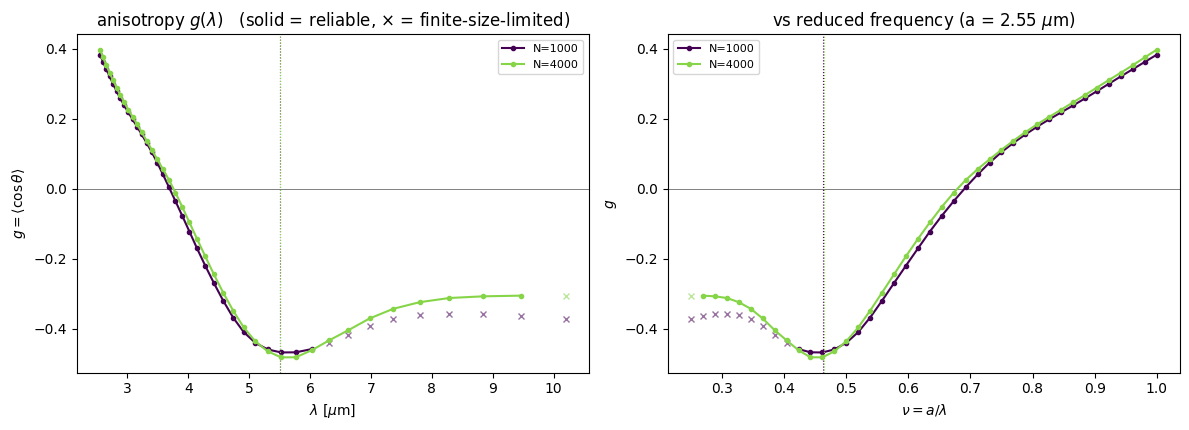

N= 1000: reliable g in [-0.468, +0.384]  (over 31 pts, lambda <= 6.03 um);  3-D vs radial max|dg| = 0.027
N= 4000: reliable g in [-0.482, +0.398]  (over 39 pts, lambda <= 9.47 um);  3-D vs radial max|dg| = 0.025


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
for a in ax: a.axhline(0, c="grey", lw=.7)
colors = plt.cm.viridis(np.linspace(0, 0.82, len(results)))
for R, c in zip(results, colors):
    rel = R["reliable"]; lab = f"N={R['N']}"
    ax[0].plot(lams[rel], R["g_avg"][rel], "o-", ms=3, color=c, label=lab)
    ax[1].plot(nus[rel],  R["g_avg"][rel], "o-", ms=3, color=c, label=lab)
    if (~rel).any():
        ax[0].plot(lams[~rel], R["g_avg"][~rel], "x", ms=5, color=c, alpha=.55)
        ax[1].plot(nus[~rel],  R["g_avg"][~rel], "x", ms=5, color=c, alpha=.55)
    ax[0].axvline(R["lam_gap"], ls=":", c=c, lw=.8)
    ax[1].axvline(a_nu/R["lam_gap"], ls=":", c=c, lw=.8)
ax[0].set(xlabel=r"$\lambda$ [$\mu$m]", ylabel=r"$g=\langle\cos\theta\rangle$",
          title=r"anisotropy $g(\lambda)$   (solid = reliable, $\times$ = finite-size-limited)")
ax[0].legend(fontsize=8)
ax[1].set(xlabel=r"$\nu = a/\lambda$", ylabel=r"$g$", title=f"vs reduced frequency (a = {a_nu:.2f} $\\mu$m)")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

for R in results:
    rel = R["reliable"]
    print(f"N={R['N']:>5}: reliable g in [{R['g_avg'][rel].min():+.3f}, {R['g_avg'][rel].max():+.3f}]  "
          f"(over {int(rel.sum())} pts, lambda <= {lams[rel].max():.2f} um);  "
          f"3-D vs radial max|dg| = {np.max(np.abs((R['g_avg']-R['g_iso'])[rel])):.3f}")

## 7. Save

In [ ]:
import h5py, os
if SAVE:
    os.makedirs("Structures", exist_ok=True)
    out = f"Structures/anisotropy_g_{SAVE_TAG}.h5"
    with h5py.File(out, "w") as h:
        h.attrs.update(dict(n_rod=N_ROD, n_bg=N_BG, minor_radius=MINOR_RADIUS, aspect_ratio=ASPECT_RATIO,
            target_dx=TARGET_DX, sweep_by=SWEEP_BY, a_scale=a_nu, polarized=POLARIZED, min_ewald_modes=MIN_EWALD_MODES))
        h.create_dataset("lambda_um", data=lams)
        h.create_dataset("nu", data=nus)
        for i, (f, R) in enumerate(zip(ENDS_FILES, results)):
            grp = h.create_group(f"file{i}_N{R['N']}")
            grp.attrs.update(dict(ends_file=f, N=R["N"], box=R["box"], grid=R["G"], ff=R["ff"],
                                n_av=R["n_av"], n_eff=R["n_eff"], q_peak=R["q_peak"], lam_gap=R["lam_gap"]))
            grp.create_dataset("g_avg", data=R["g_avg"])
            grp.create_dataset("g_iso", data=R["g_iso"])
            grp.create_dataset("reliable", data=R["reliable"])
    print("saved", out)

saved Structures/anisotropy_g_sweep.h5


## Summary & validity map

**Reliable deliverable — $g(\lambda)$** (single-scattering, normalized), for each input network on your chosen
sweep. Faithful in the **ISA / weak-scattering window** — off-gap and above the finite-size floor
($k\,\ell_s\gg1$; the Ewald sphere spans $\ge$ `MIN_EWALD_MODES` $q$-shells). There it *is* the
structure-factor-weighted transport anisotropy, so $\ell_t=\ell_s/(1-g)$ is valid **if** you supply a
full-wave $\ell_s$.

**Where $g$ is NOT reliable** (both shown/flagged, not hidden):
- **At the photonic gap** ($2k_\mathrm{eff}\!\approx\!q_\mathrm{FSDP}$, dotted lines): no diffusion —
  dependent/recurrent + Bragg backscattering dominate; the single-scattering $g$ is not a transport quantity.
- **Long $\lambda$** ($\times$ markers): finite-size-limited. The persistent negative-$g$ tail is an
  **artifact**; physically $g\to0$ (Rayleigh). Reach grows only as $N^{1/3}$ — overlay a bigger cell to
  extend it (or ensemble-average several cells to cut low-$q$ noise, which does *not* extend the reach).

**NOT computed here — needs full-wave / FDTD (see README):** $\ell_s$ (coherent-field amplitude decay
$\propto e^{-z/2\ell_s}$; the analytic strong-contrast/Born $\ell_s$ *fails at the gap* and isn't quantitative
at high contrast); $\ell_t$ (measure **directly** — Ohm's-law $T(L)\propto\ell_t/L$, or time-resolved
$D\to\ell_t=3D/v_E$ with the renormalized energy velocity $v_E\ll c/n$); the **DOS / gap / localization
length** (supercell band structure, e.g. MPB). All physics here is single-scattering / effective-medium — no FDTD.